# Pilot 2025 Data Review

This notebook is the pilot-scale counterpart of the laboratory MBDoE workflow. The objective of this first stage is not parameter estimation yet. The objective is to verify that the data can be loaded, normalized, aligned in time, and interpreted before the calibration and estimability pipeline is re-used.

The pilot system uses natural must, so the future design space is narrower than the synthetic-must laboratory campaign. In exchange, the dataset has richer observations for the aroma mass balance, especially ethyl acetate and isoamyl acetate.

## Model-Relevant Data Mapping

The extended fermentation model uses the following observation groups:

- Primary fermentation states: viable biomass, glucose, fructose, assimilable nitrogen, ethanol, glycerol, and temperature input.
- Secondary states: pyruvic acid and acetaldehyde. Acetic acid is included if available.
- Aroma states: total-equivalent and condenser-equivalent observations for ethyl acetate, isoamyl acetate, and ethyl octanoate.
- Online gas information: CO2 sensor trajectories for the subset of batches with sensor files.

Aroma `*_total` columns are interpreted as the total equivalent concentration in wine plus condenser. Aroma `*_condensate` columns are interpreted as the equivalent must concentration accumulated in the condenser. Therefore the retained wine pool can be reconstructed as `total - condensate` when both are measured.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

SCRIPT_DIR = Path.cwd()
if SCRIPT_DIR.name != 'pilot_2025':
    SCRIPT_DIR = Path('fermentation_model/pilot_2025').resolve()
sys.path.insert(0, str(SCRIPT_DIR))
import pilot_2025_data_loader as loader

data = loader.load_pilot_calibration_data()
raw_co2 = loader.load_all_co2_sensor_data(calibration_data=data)
co2, co2_decisions = loader.curate_co2_sensor_data(raw_co2)
coverage = loader.observation_coverage(data)
density_fit = loader.fit_density_total_sugar(data)
data.shape, raw_co2.shape, co2.shape

((312, 48), (42989, 5), (40591, 9))

## Fermentation Sheets and Observation Coverage

In [2]:
coverage

,batch,n_rows,t_min_h,t_max_h,n_temperature_c,n_density,n_S_GF_g_l,n_X_viable_kg_m3,n_X_dry_weight_g_l,n_YAN_mg_l,...,n_pyruvic_acid_mg_l,n_acetaldehyde_mg_l,n_acetic_acid_g_l,n_E_g_l,n_ethyl_acetate_total,n_ethyl_acetate_condensate,n_isoamyl_acetate_total,n_isoamyl_acetate_condensate,n_ethyl_octanoate_total,n_ethyl_octanoate_condensate
0,25026,24,0.0,138.0,24,24,11,11,10,11,...,11,0,0,11,5,4,5,4,5,4
1,25027,32,0.0,186.0,32,32,13,13,12,13,...,13,0,0,13,5,4,5,4,5,4
2,25085,35,0.0,216.0,35,34,17,17,17,17,...,17,17,0,17,5,4,5,4,5,4
3,25086,35,0.0,216.0,35,34,17,17,17,17,...,17,17,0,17,5,4,5,4,5,4
4,25150,30,0.0,174.0,30,30,14,14,14,14,...,13,14,0,14,6,5,6,5,6,5
5,25151,30,0.0,174.0,30,30,14,14,14,14,...,13,14,0,14,6,5,6,5,6,5
6,25170,63,0.0,372.0,63,63,26,23,26,24,...,26,26,0,26,11,10,11,10,11,10
7,25171,63,0.0,372.0,63,63,26,22,26,24,...,26,26,0,26,9,8,9,8,9,8


## Unit Checks

The `ETANOL` column is interpreted as g/L. Its final values are close to 95 g/L, which is realistic for wine. Interpreting the same values as % v/v would be physically impossible.

In [3]:
unit_cols = ['batch', 'time_h', 'E_g_l', 'E_percent_vv', 'S_GF_g_l', 'density', 'X_viable_kg_m3', 'X_dry_weight_g_l']
data[unit_cols].groupby('batch').agg(['count', 'min', 'median', 'max'])

time_h                    E_g_l                                   \
       count  min median    max count        min     median        max   
batch                                                                    
25026     24  0.0   69.0  138.0    11   6.154200  83.851970  98.281967   
25027     32  0.0   93.0  186.0    13   5.425713  74.457791  96.573600   
25085     35  0.0  108.0  216.0    17   9.791790  79.019673  95.414835   
25086     35  0.0  108.0  216.0    17  10.888351  78.520867  95.311200   
25150     30  0.0   87.0  174.0    14   8.273426  71.826892  94.522200   
25151     30  0.0   87.0  174.0    14   8.273139  73.344019  94.127700   
25170     63  0.0  186.0  372.0    26   6.560923  63.174122  95.390100   
25171     63  0.0  186.0  372.0    26   6.927519  58.904249  93.891000   

      E_percent_vv            ... density         X_viable_kg_m3          \
             count       min  ...  median     max          count     min   
batch                         ...                                          
25026           11  0.779763  ...  1012.0  1066.0             11  0.4770   
25027           13  0.687461  ...  1012.5  1065.0             13  0.0828   
25085           17  1.240661  ...  1011.5  1061.0             17  0.4494   
25086           17  1.379599  ...  1011.5  1064.0             17  0.4356   
25150           14  1.048278  ...  1010.0  1059.0             14  0.3711   
25151           14  1.048241  ...  1009.0  1059.0             14  0.4701   
25170           26  0.831296  ...  1014.0  1061.0             23  0.3087   
25171           26  0.877745  ...  1018.0  1062.0             22  0.2142   

                       X_dry_weight_g_l                           
        median     max            count     min   median     max  
batch                                                             
25026  1.60830  3.1083               10  0.0514  0.20835  0.3000  
25027  1.52310  2.6244               12 -0.0145  0.20505  0.3480  
25085  1.32030  2.2305               17  0.0241  0.18930  0.3035  
25086  1.29030  1.9032               17 -0.0021  0.17100  0.3795  
25150  1.43895  2.1705               14  0.0288  0.21440  0.3286  
25151  1.23270  2.7282               14  0.0172  0.20330  0.2684  
25170  0.97230  2.0946               26  0.0259  0.17500  0.2845  
25171  1.15785  1.8870               26  0.0116  0.22330  0.4523  

[8 rows x 28 columns]

## Density as Total Sugar Proxy

Density is useful because it is measured more frequently than glucose and fructose. The linear relationship below estimates the information loss incurred when using density as a proxy for total sugar.

DensitySugarFit(intercept=-2024.5393518810758, slope=2.0363234329914817, r2=0.9869141516975135, rmse_g_l=5.815905161643351, n_points=136)


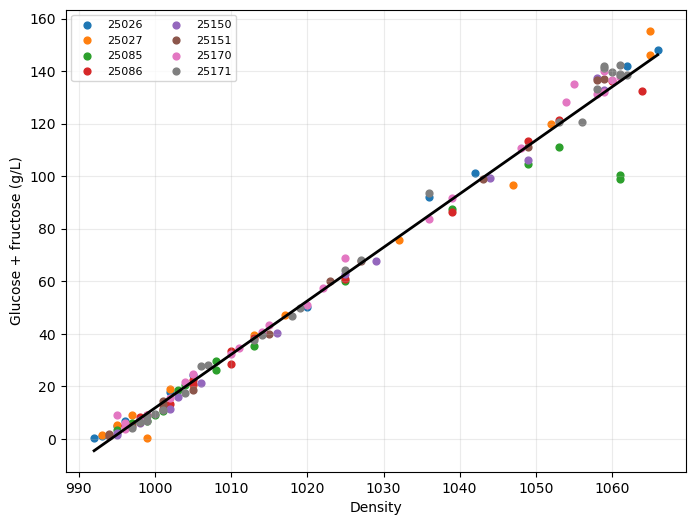

In [4]:
print(density_fit)
df = data[['batch', 'density', 'S_GF_g_l']].dropna()
fig, ax = plt.subplots(figsize=(8, 6))
for batch, group in df.groupby('batch'):
    ax.scatter(group['density'], group['S_GF_g_l'], label=batch, s=24)
x = pd.Series([df['density'].min(), df['density'].max()])
ax.plot(x, density_fit.predict(x), color='black', linewidth=2)
ax.set_xlabel('Density')
ax.set_ylabel('Glucose + fructose (g/L)')
ax.grid(True, alpha=0.25)
ax.legend(ncol=2, fontsize=8)
plt.show()

## Batch Trajectories

These plots are intended to detect unit problems, missing-data patterns, and whether pilot trajectories excite the same parameter directions as the laboratory designs.

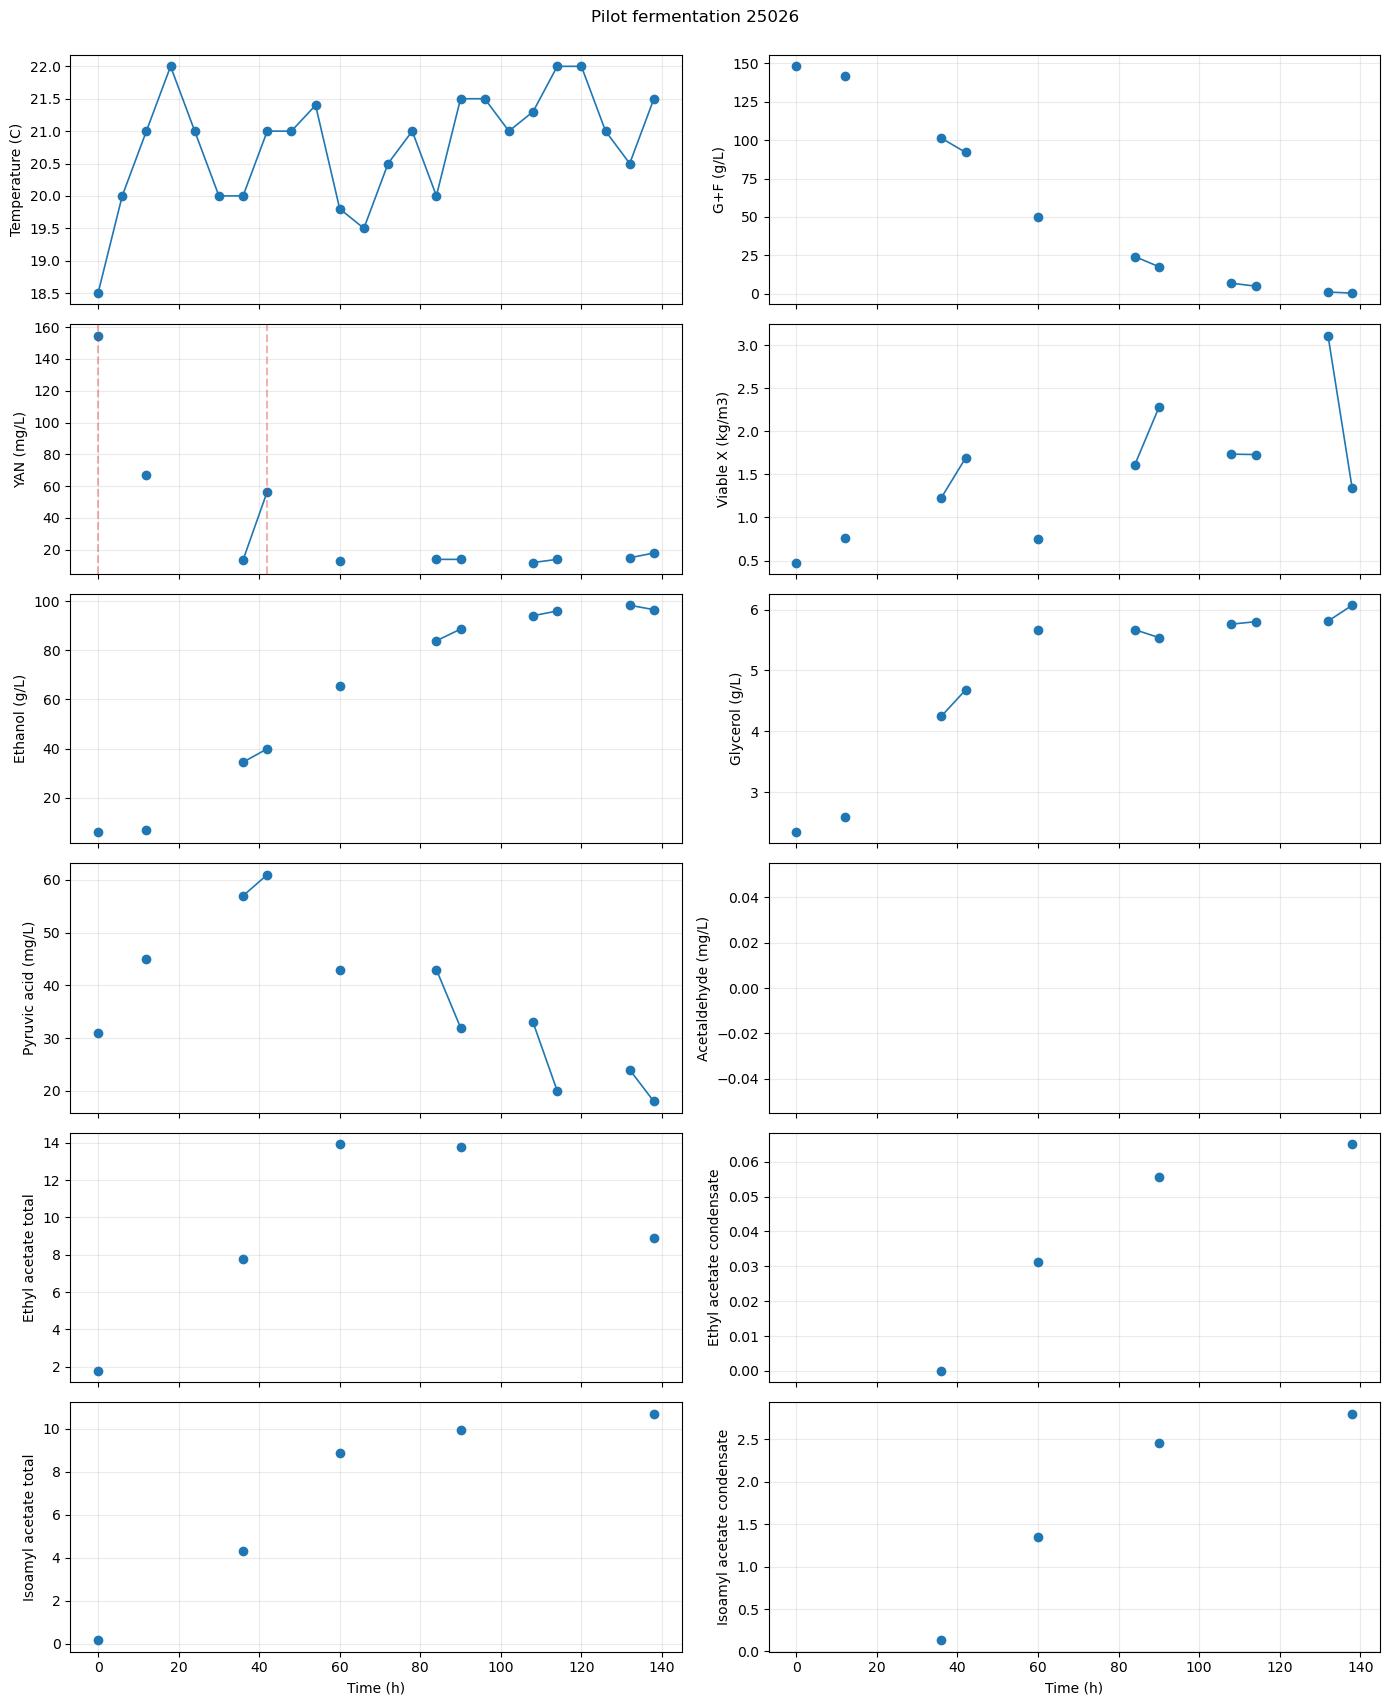

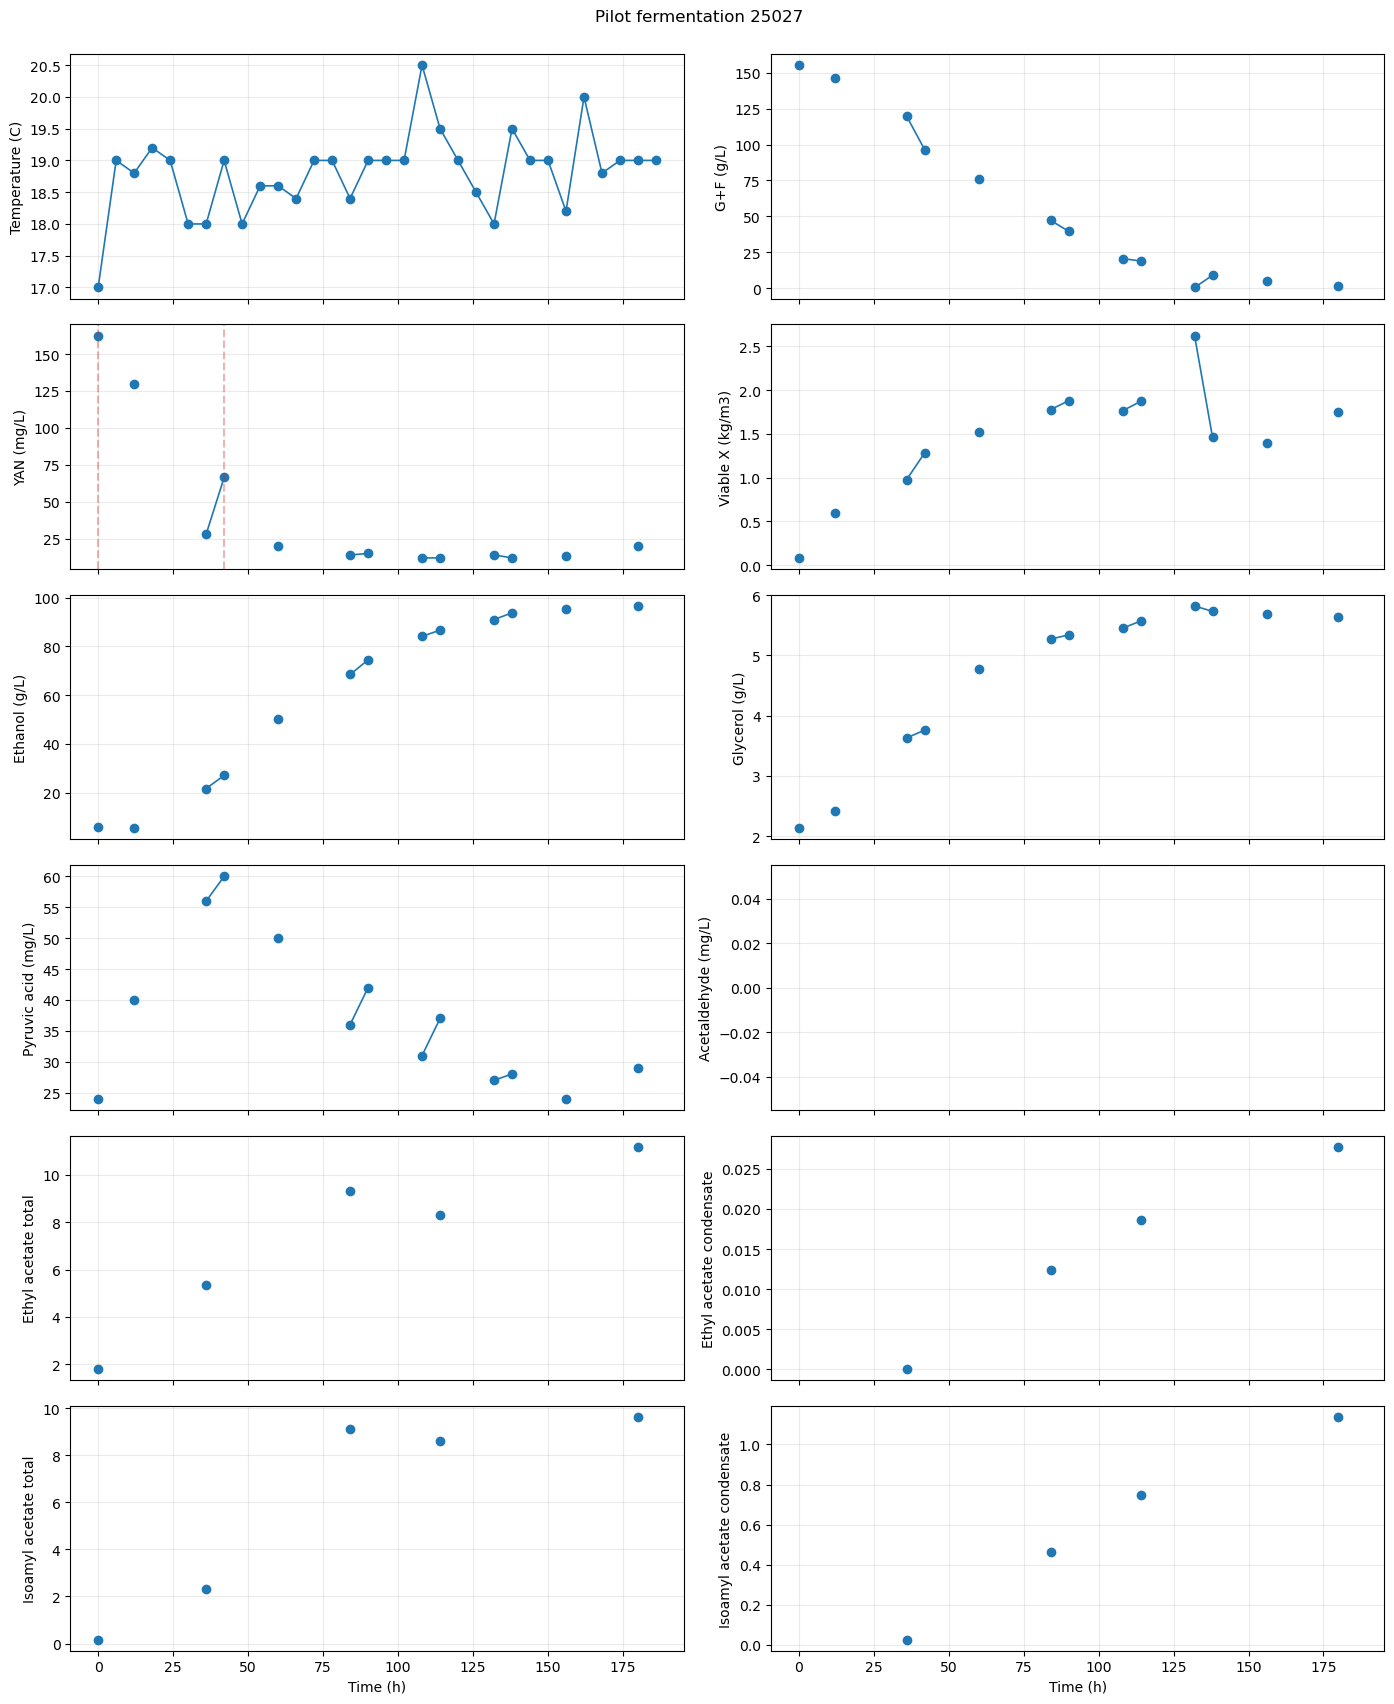

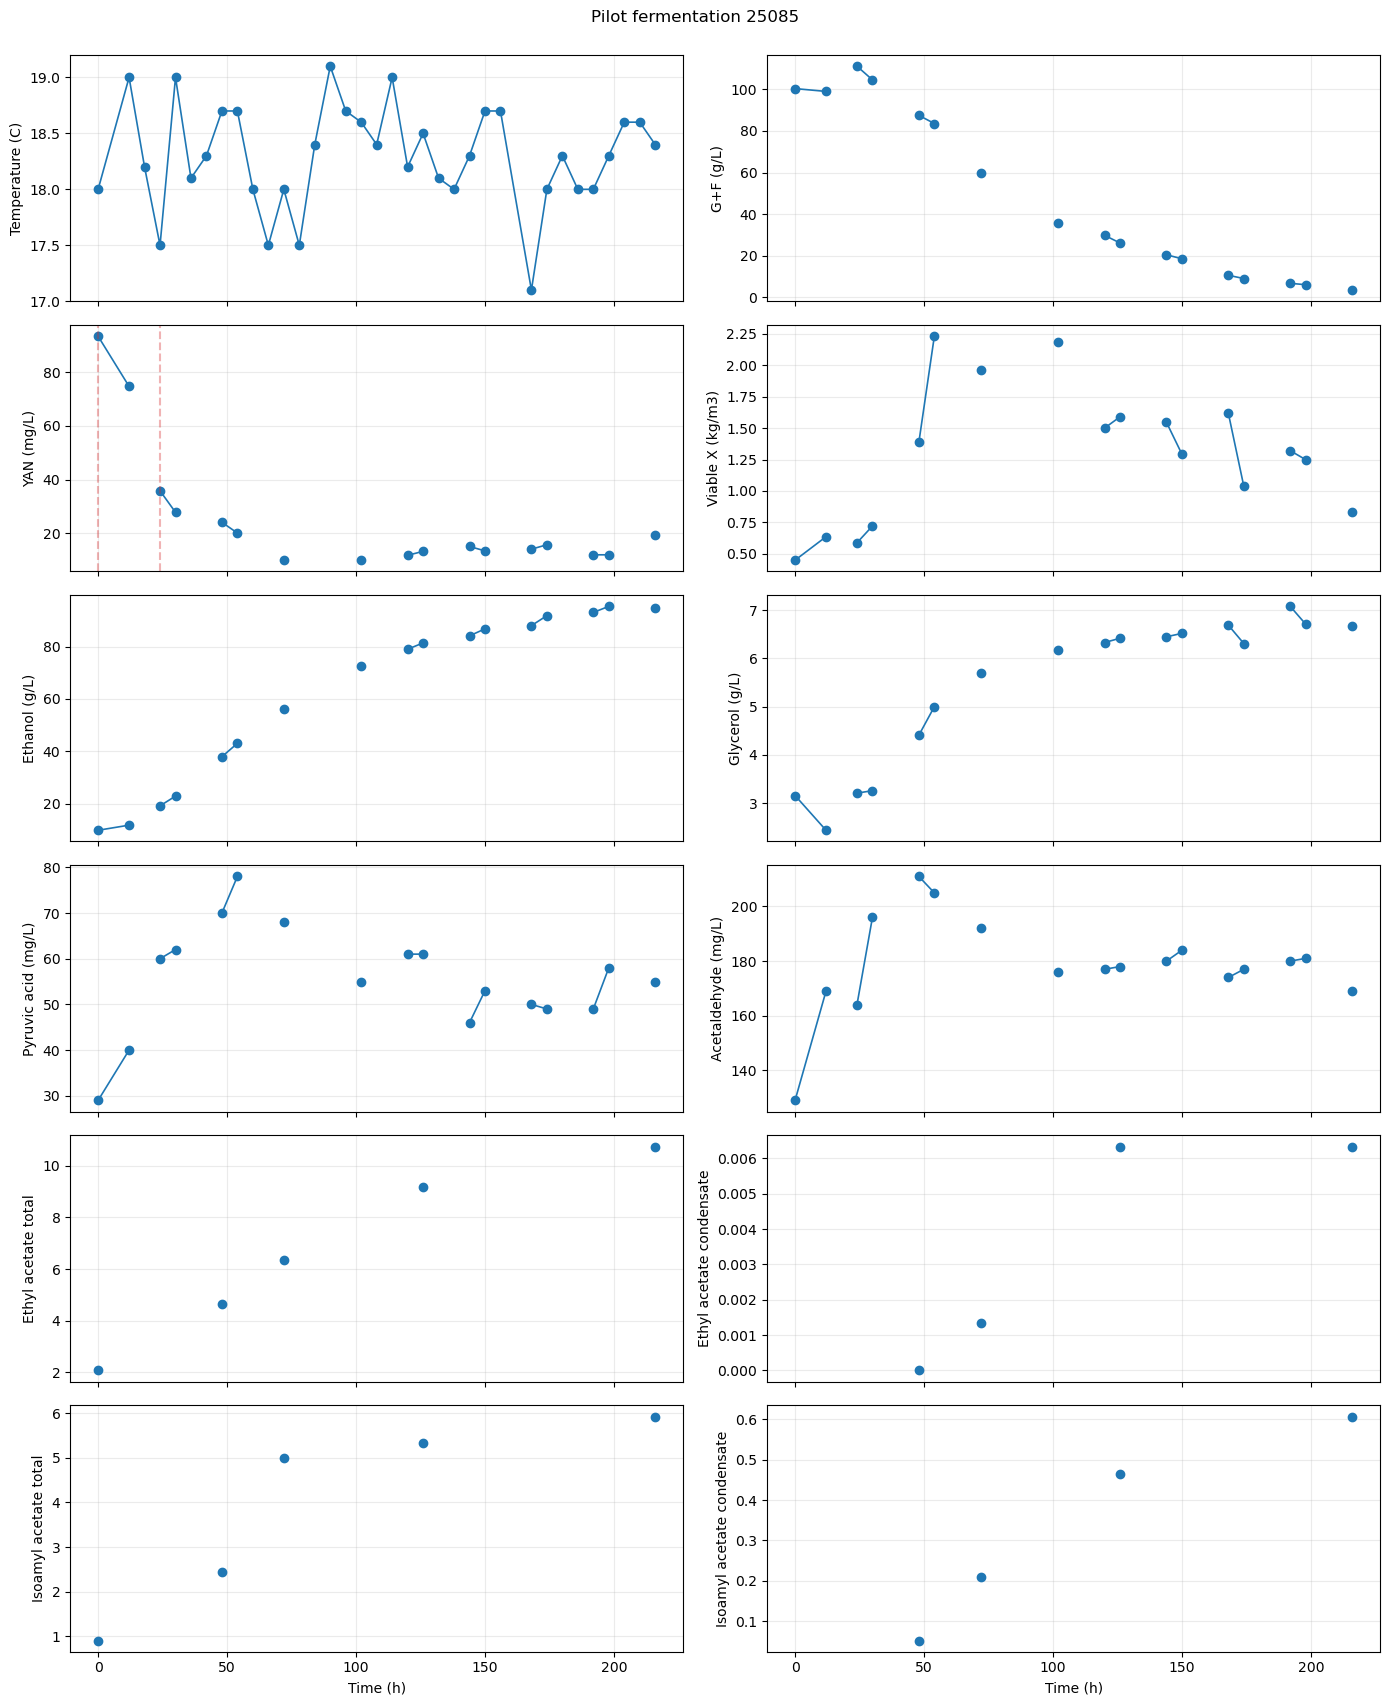

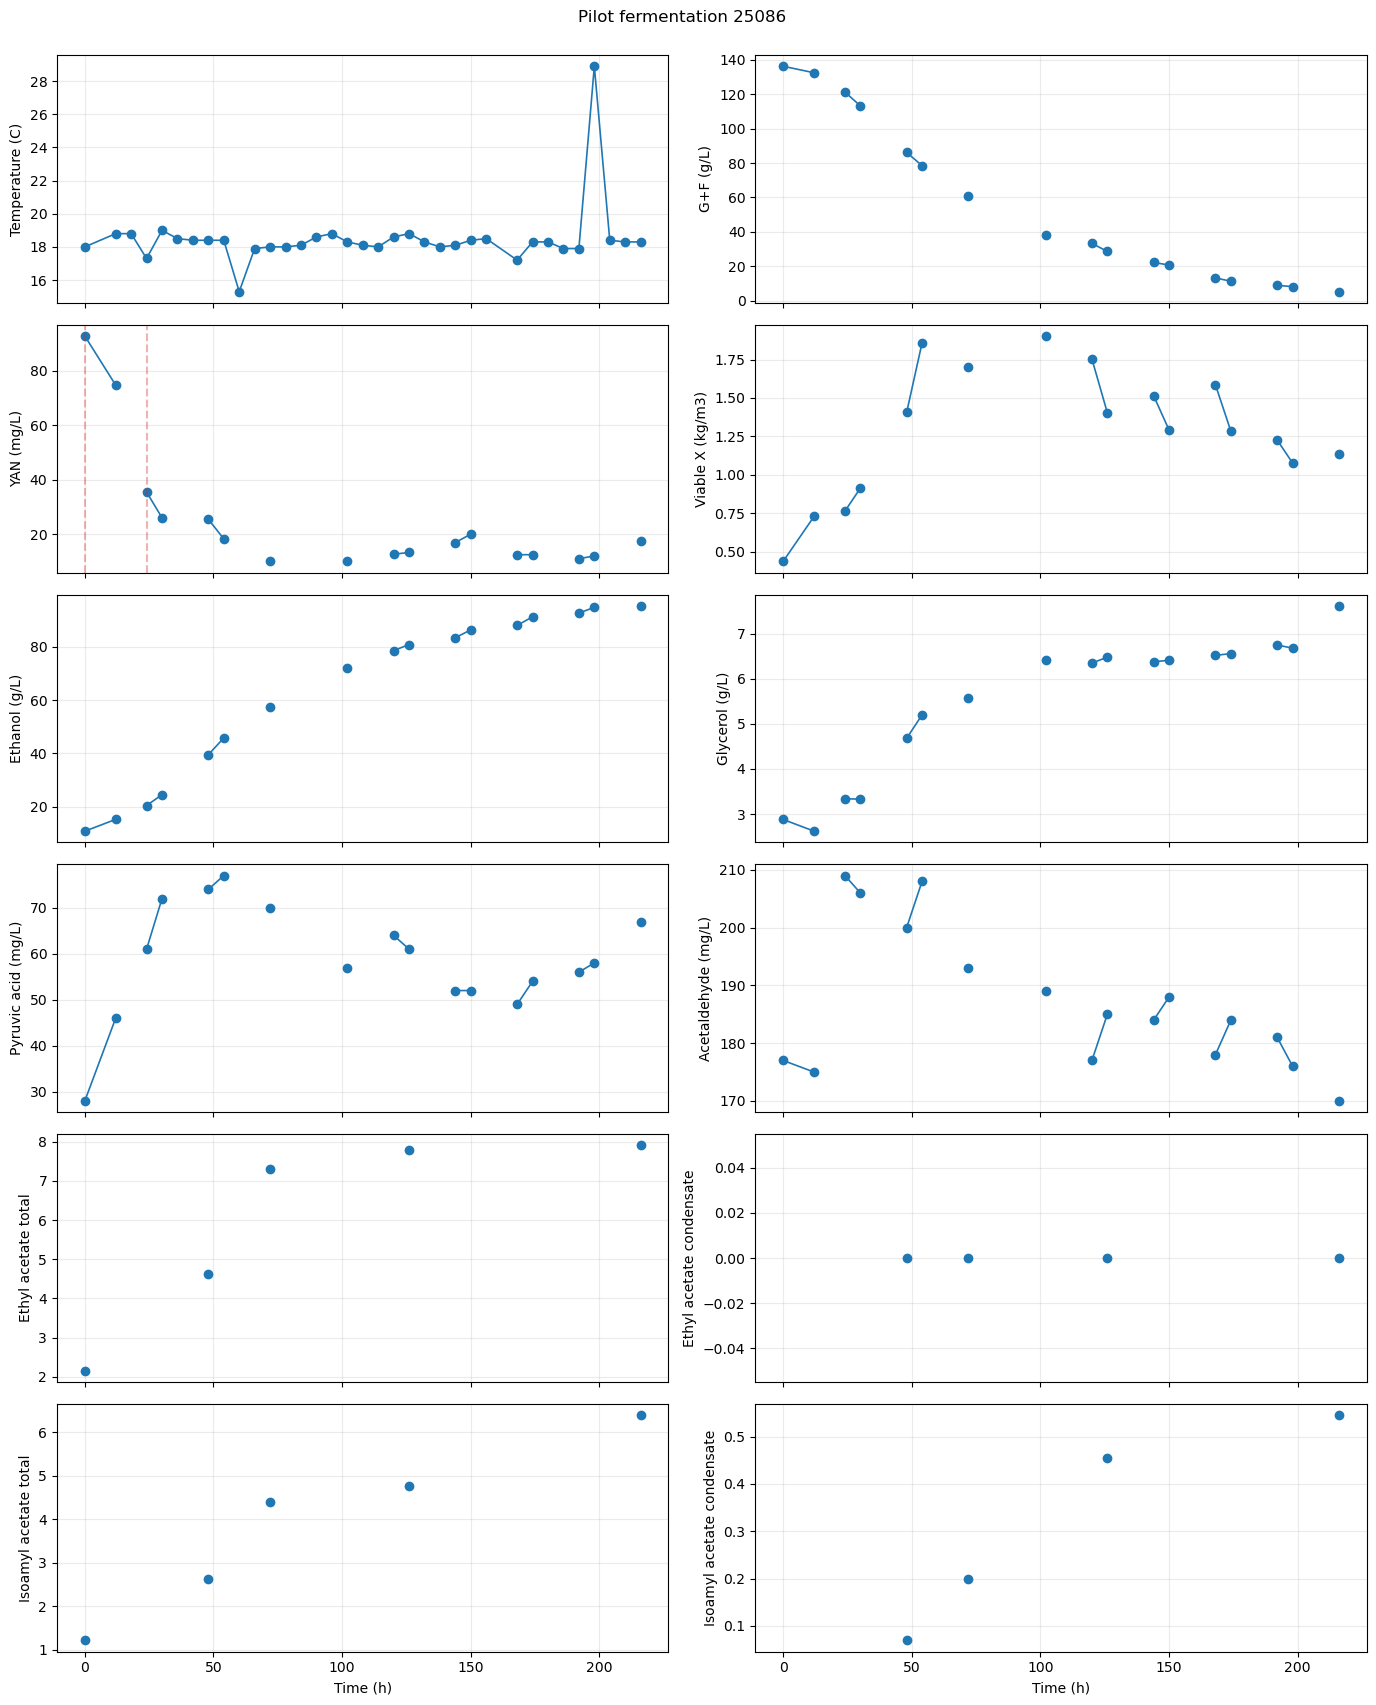

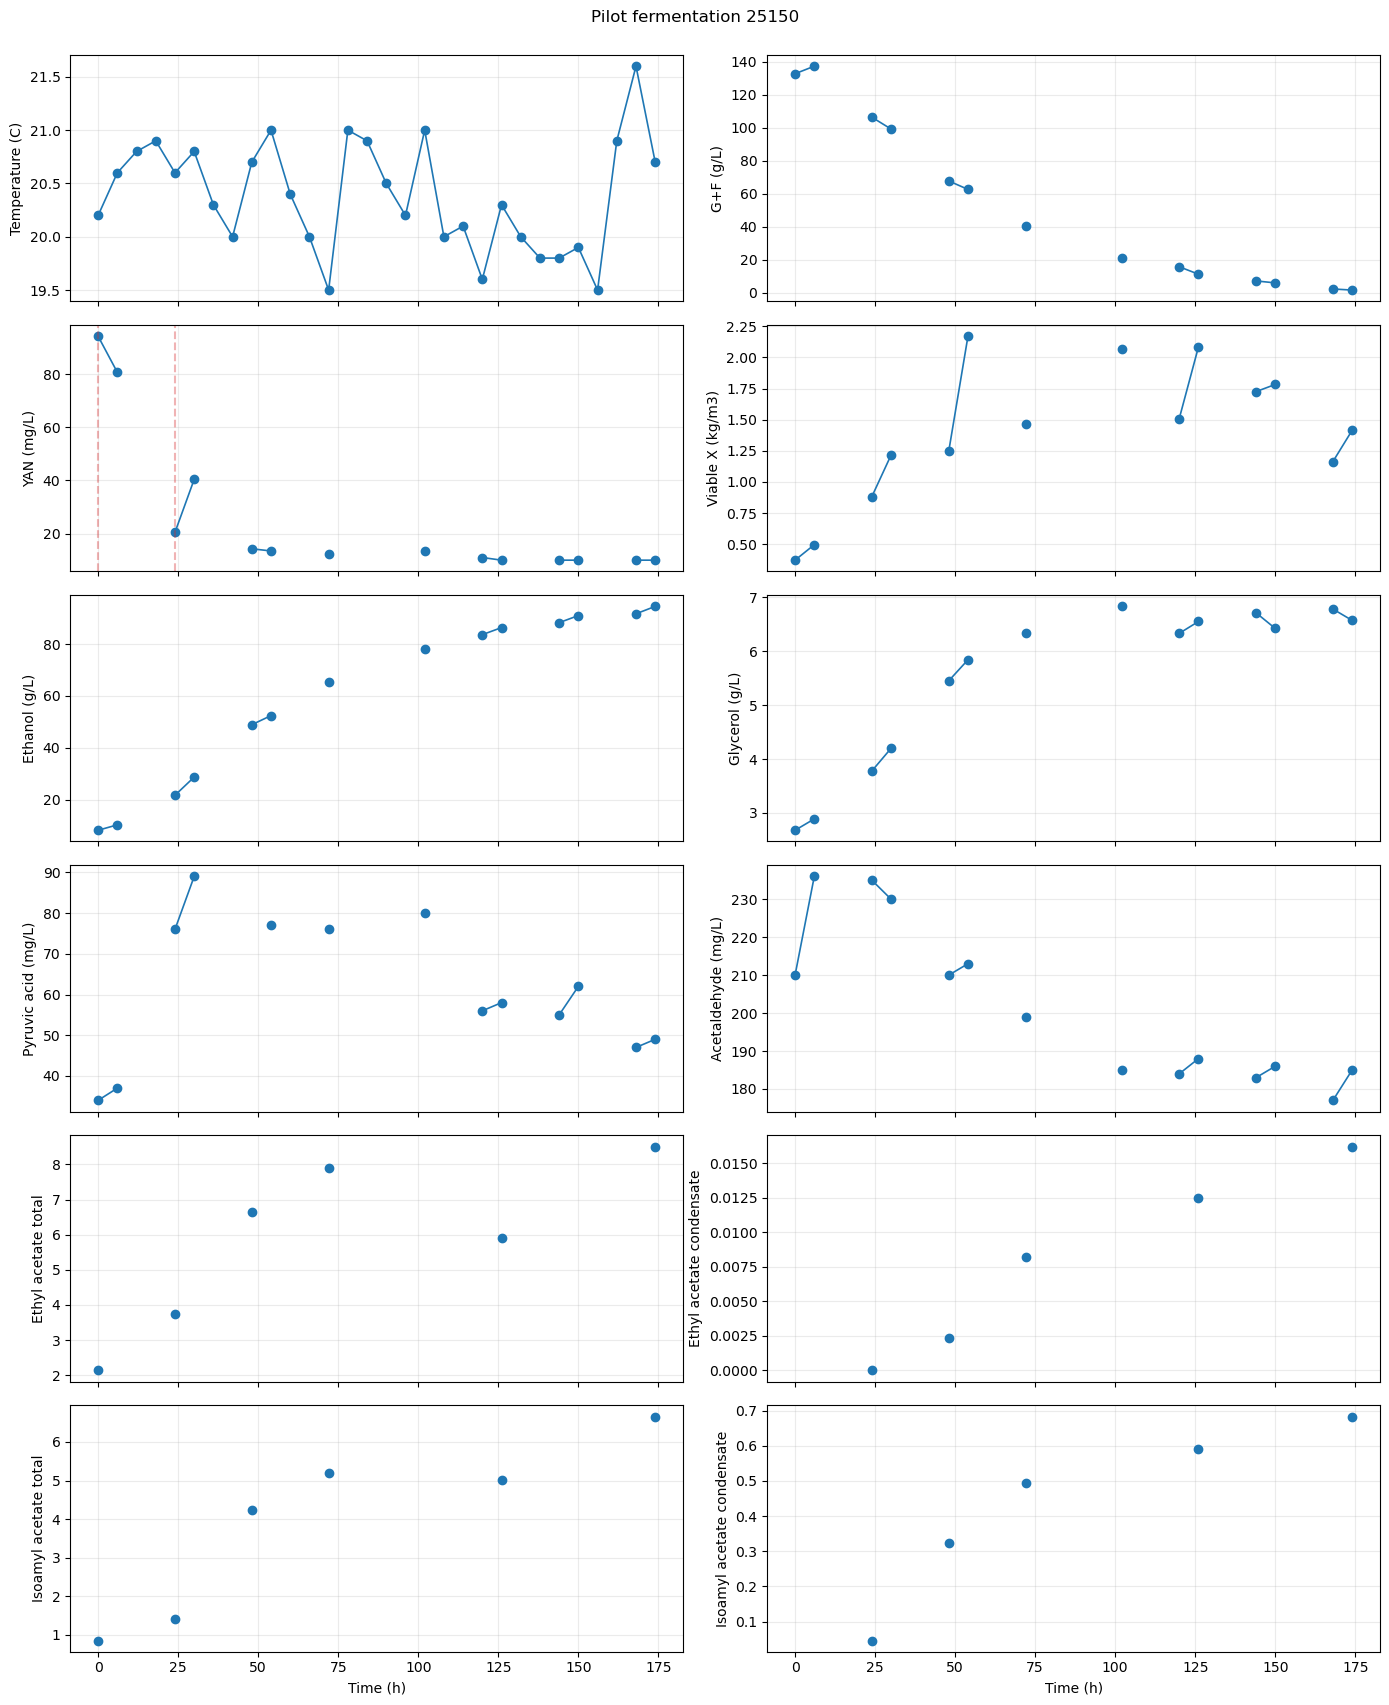

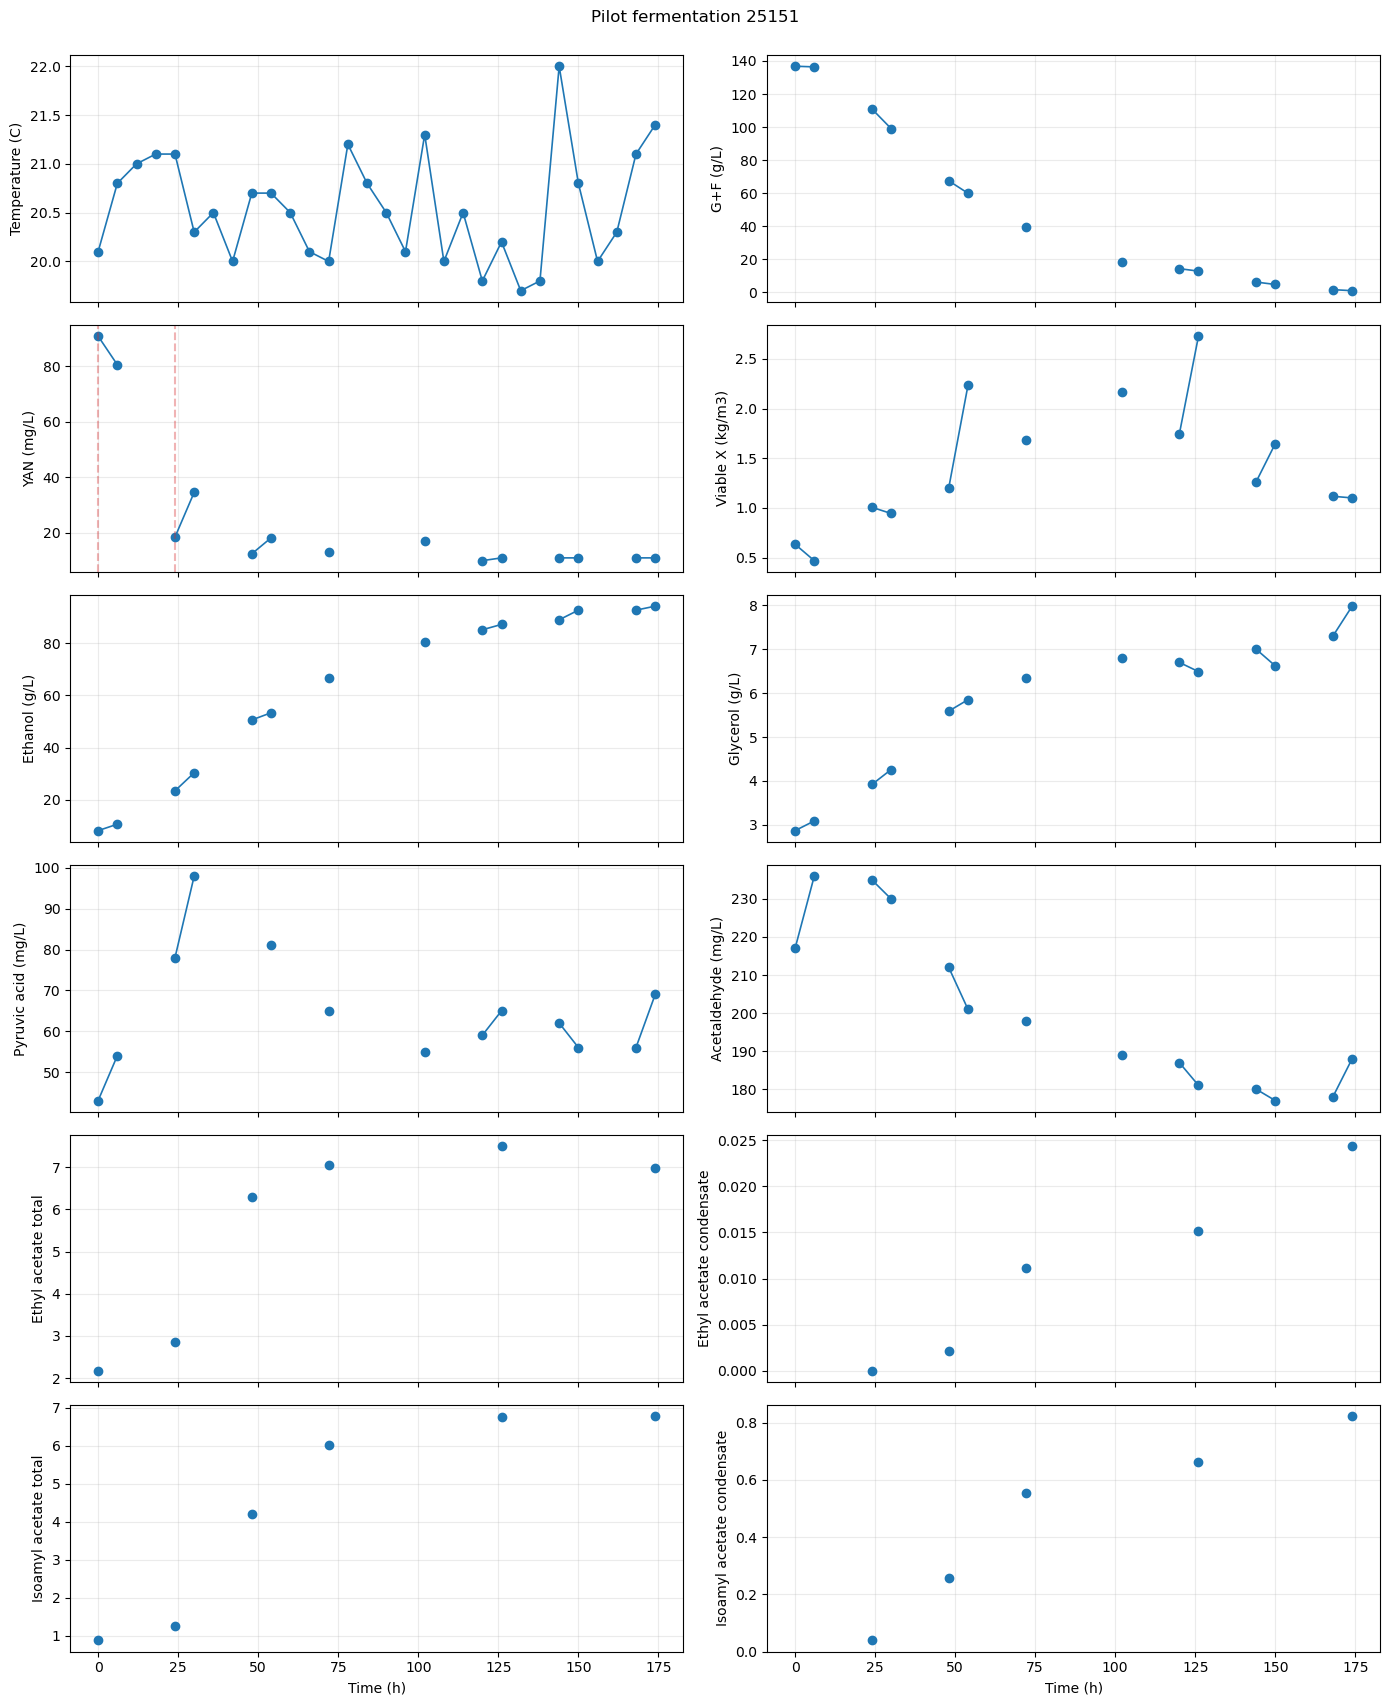

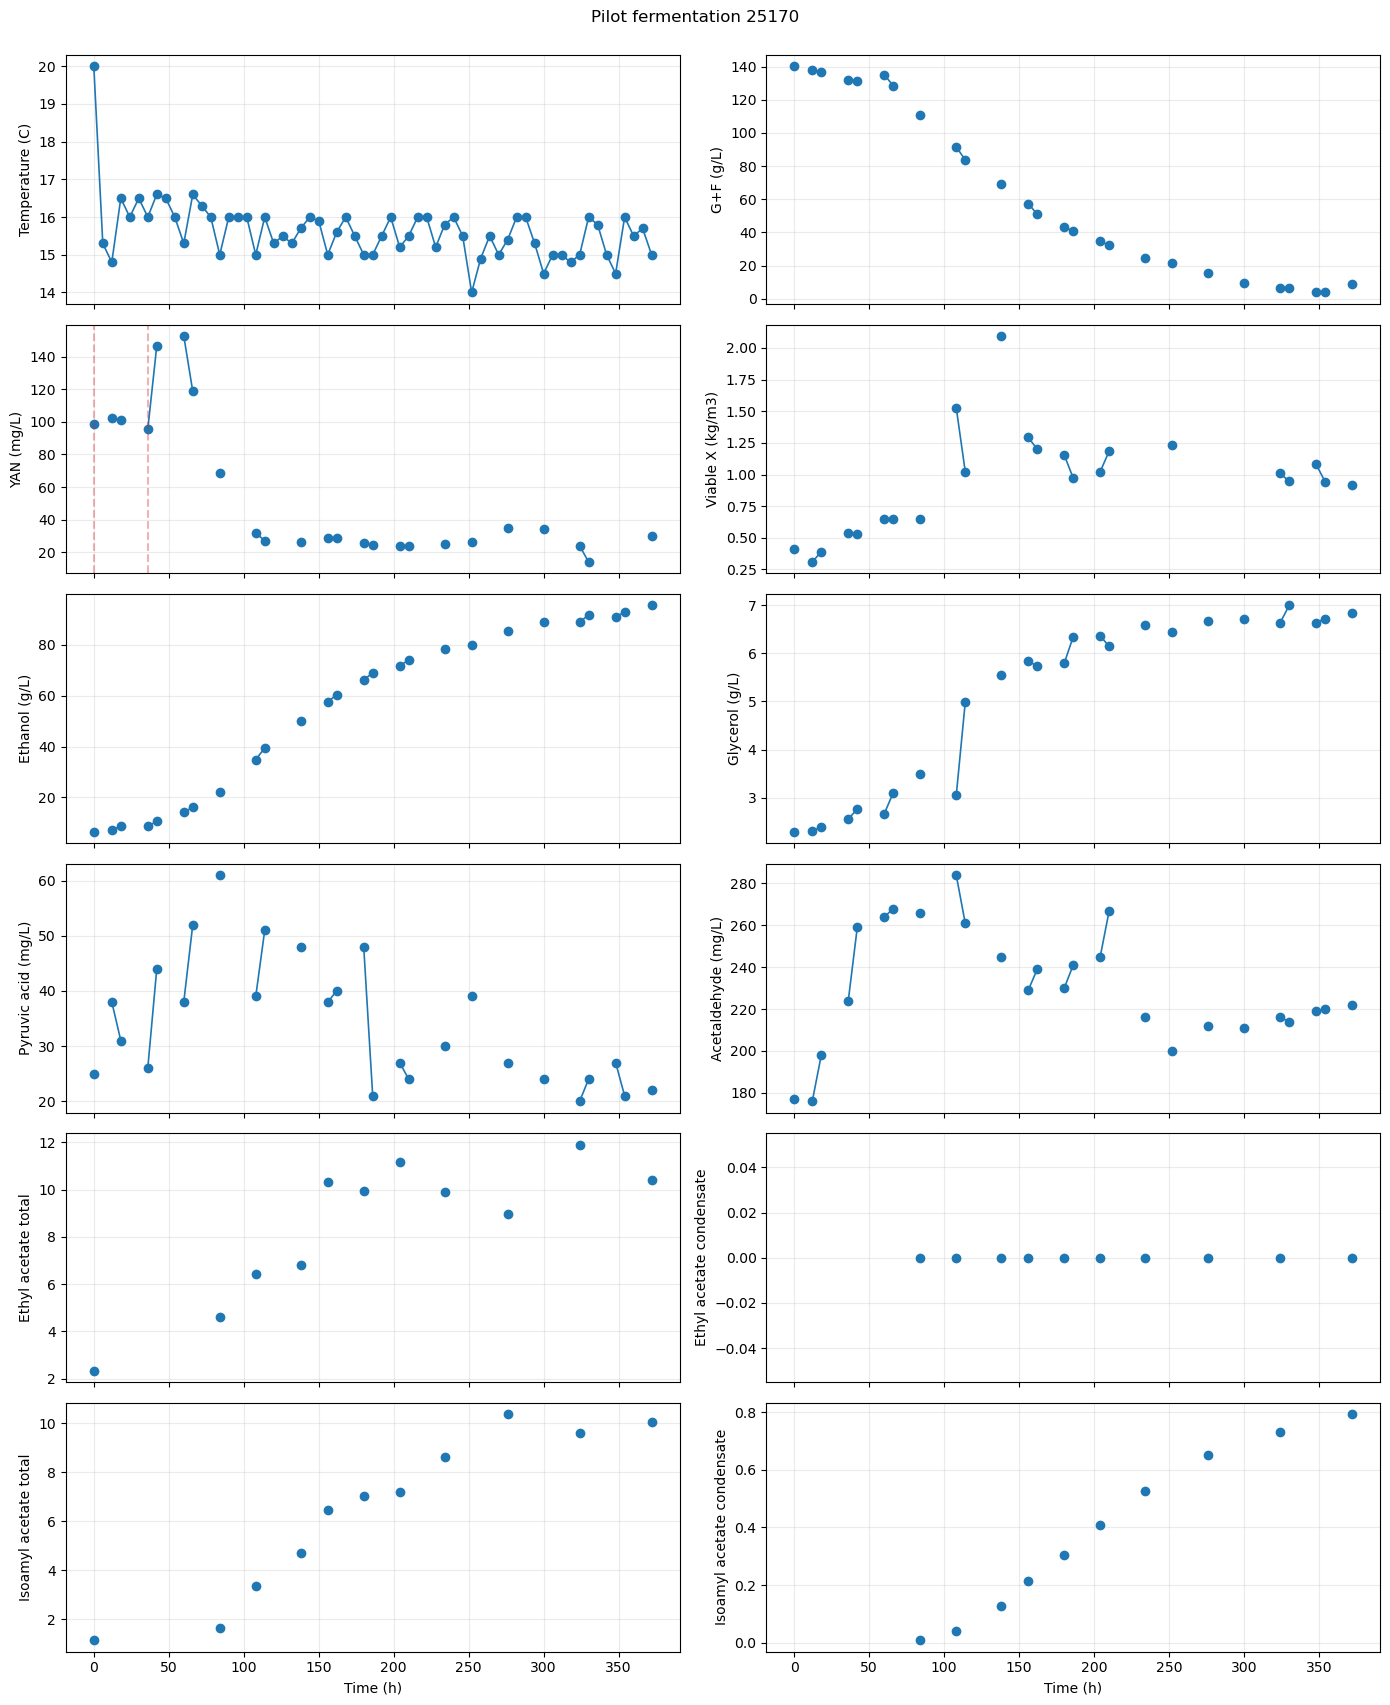

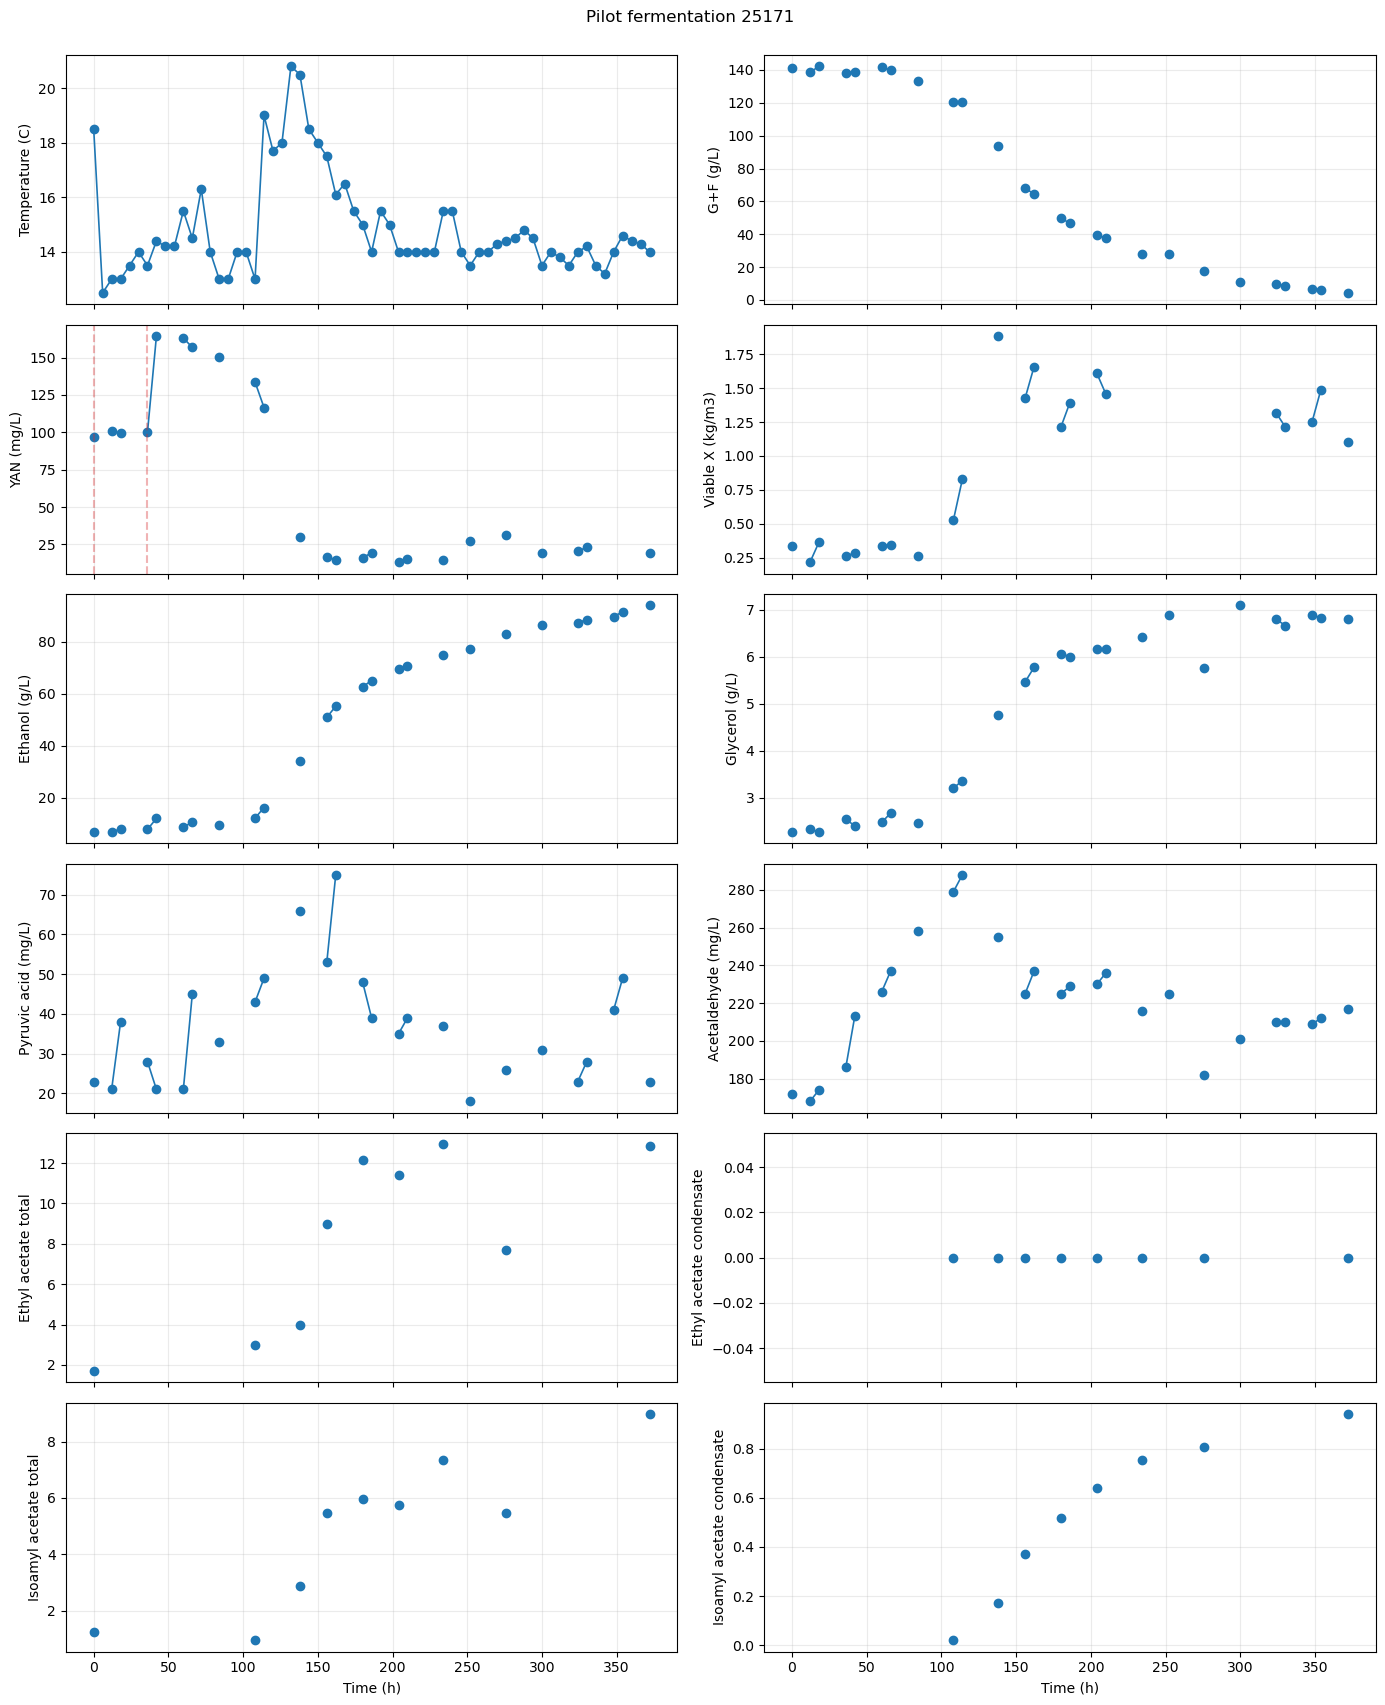

In [5]:
states = [
    ('temperature_c', 'Temperature (C)'), ('S_GF_g_l', 'G+F (g/L)'),
    ('YAN_mg_l', 'YAN (mg/L)'), ('X_viable_kg_m3', 'Viable X (kg/m3)'),
    ('E_g_l', 'Ethanol (g/L)'), ('glycerol_g_l', 'Glycerol (g/L)'),
    ('pyruvic_acid_mg_l', 'Pyruvic acid (mg/L)'), ('acetaldehyde_mg_l', 'Acetaldehyde (mg/L)'),
    ('ethyl_acetate_total', 'Ethyl acetate total'), ('ethyl_acetate_condensate', 'Ethyl acetate condensate'),
    ('isoamyl_acetate_total', 'Isoamyl acetate total'), ('isoamyl_acetate_condensate', 'Isoamyl acetate condensate'),
]
for batch, group in data.groupby('batch'):
    fig, axes = plt.subplots(6, 2, figsize=(14, 17), sharex=True)
    for ax, (col, ylabel) in zip(axes.ravel(), states):
        ax.plot(group['time_h'], group[col], marker='o', linewidth=1.2)
        if col == 'YAN_mg_l':
            pulses = group[group['N_pulse_mg_l'].fillna(0).gt(0)]
            for _, pulse in pulses.iterrows():
                ax.axvline(float(pulse['time_h']), color='tab:red', linestyle='--', alpha=0.35)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.25)
    axes[-1, 0].set_xlabel('Time (h)')
    axes[-1, 1].set_xlabel('Time (h)')
    fig.suptitle(f'Pilot fermentation {batch}', y=1.0)
    fig.tight_layout()
    plt.show()

## Online CO2 Sensor Files

The raw sensor files are first aligned against the first timestamp in the corresponding fermentation sheet. For calibration, `25150` and `25151` are excluded. For `25171`, the pre-activation segment is removed and an effective CO2 time is created with the sustained activation point as `t = 0`.

In [6]:
co2_decisions

,batch,raw_rows,used_for_calibration,reason,activation_time_h,curated_rows
0,25150,56,False,excluded: CO2 file not usable for this batch,NaN,0
1,25151,56,False,excluded: CO2 file not usable for this batch,NaN,0
2,25170,22877,True,kept,0.000000,22837
3,25171,20000,True,trimmed to sustained CO2 activation,36.802778,17754


In [7]:
co2_summary = co2.groupby('batch').agg(
    n_rows=('co2_raw', 'size'), t_original_min_h=('time_h_original', 'min'), t_original_max_h=('time_h_original', 'max'),
    t_effective_min_h=('time_h_effective', 'min'), t_effective_max_h=('time_h_effective', 'max'),
    co2_min=('co2_raw', 'min'), co2_median=('co2_raw', 'median'), co2_max=('co2_raw', 'max')
).reset_index()
co2_summary

,batch,n_rows,t_original_min_h,t_original_max_h,t_effective_min_h,t_effective_max_h,co2_min,co2_median,co2_max
0,25170,22837,0.005833,380.711389,0.005833,380.711389,0.0,0.305313,4.798518
1,25171,17754,36.802778,332.777222,0.000000,295.974444,0.0,0.273710,3.613556


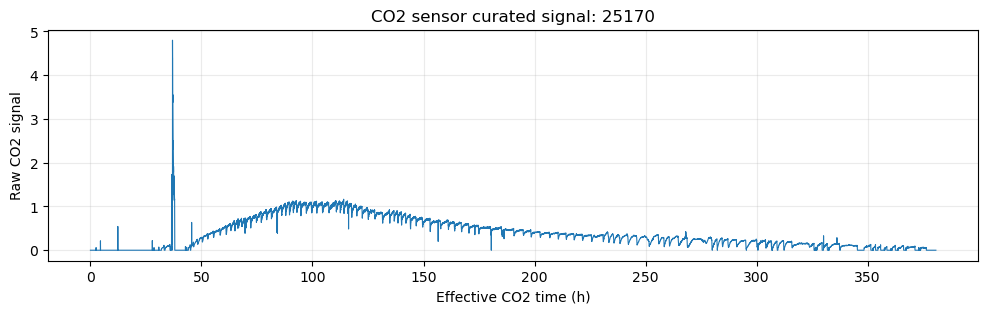

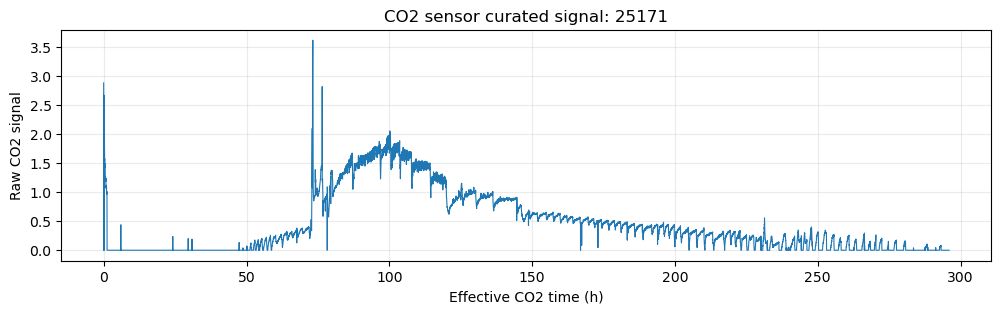

In [8]:
for batch, group in co2.groupby('batch'):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(group['time_h_effective'], group['co2_raw'], linewidth=0.8)
    ax.set_title(f'CO2 sensor curated signal: {batch}')
    ax.set_xlabel('Effective CO2 time (h)')
    ax.set_ylabel('Raw CO2 signal')
    ax.grid(True, alpha=0.25)
    plt.show()

## Immediate Technical Conclusions

1. The pilot workbook is usable for the extended model workflow.
2. Ethanol should be treated as g/L in this dataset.
3. The pilot data are especially valuable for ethyl acetate and isoamyl acetate because these are measured repeatedly in several fermentations.
4. The design problem should be reformulated for natural must: temperature policy and nutrient additions are realistic control levers, while arbitrary initial glucose/fructose composition and sugar pulses are not primary levers.
5. The next notebook should reuse the reduced secondary/aroma model residual structure, add pilot batches as a separate dataset group, and compare estimability against the laboratory natural/synthetic datasets.